In [3]:
import sys
from pathlib import Path

# Add the project root and src directory to sys.path 
# This allows both 'from src.module' and internal imports inside src to work
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))
if str(root_path / "src") not in sys.path:
    sys.path.append(str(root_path / "src"))

import pandas as pd
import src.config as config
from src.create_plots import load_csv, create_plot
from src.create_boxplots import create_boxplot

import matplotlib.pyplot as plt
%matplotlib inline

### 1. Identify a Raw File and Display Header Data
We will pick the first available CSV in the `data/raw` folder and print all lines starting with `#`.

In [10]:
summary_csv = config.DATA_TIMESERIES / "timeseries.csv"
if not summary_csv.exists():
    print(f"Summary file not found: {summary_csv}. Run src/create_timeseries.py first.")
    df_summary = None
else:
    df_summary = pd.read_csv(summary_csv, sep=";")
    print(f"Loaded summary with {len(df_summary)} entries from {summary_csv}")

target_extension = "47"
variables_for_avg = ["MEASURE", "SSPEED"]

all_collected_averages = []

if df_summary is not None and not df_summary.empty:
    df_filtered = df_summary[df_summary["Filename"].str.contains(target_extension, na=False)]
    print(f"Found {len(df_filtered)} files in summary matching '{target_extension}'.\n")
    
    for var in variables_for_avg:
        col_name = f"{var}_Avg"
        if col_name in df_filtered.columns:
            # Ensure numeric conversion
            vals = pd.to_numeric(df_filtered[col_name], errors='coerce').dropna().tolist() # .dropna() to remove NaN values
            all_collected_averages.extend(vals)

    if all_collected_averages:
        overall_avg = sum(all_collected_averages) / len(all_collected_averages)
        print(f"--- Overall Average of all collected averages ({', '.join(variables_for_avg)}) ---")
        print(f"Total individual averages collected: {len(all_collected_averages)}")
        print(f"Overall Average: {overall_avg:.4f}")
else:
    print("Summary file not found. Run create_timeseries.py first.")

Loaded summary with 82 entries from C:\Users\ArnauCoronado\Documents_local\euromed\sxs\data\timeseries\timeseries.csv


KeyError: 'Filename'

### 4. Anàlisi Agrupada per ID de Punt
Seguint la lògica de noms `YYMMDD_HHMM_point-id_outside-diameter`, identifiquem quants punts diferents s'han analitzat i calculem la mitjana de totes les estadístiques de `MEASURE` per a cada identificador únic.

In [5]:
from collections import defaultdict
from pathlib import Path

# --- Analysis by Point ID using the loaded summary ---
target_extension_for_point_analysis = "" # Can be changed to filter specific files
variables_for_point_analysis = ["MEASURE"] # Can be changed to analyze other variables

if 'df_summary' not in locals() or df_summary is None or df_summary.empty:
    summary_csv = config.DATA_TIMESERIES / "timeseries.csv"
    if summary_csv.exists():
        df_summary = pd.read_csv(summary_csv, sep=";")
        print(f"Loaded summary with {len(df_summary)} entries from {summary_csv}")
    else:
        df_summary = None

if df_summary is not None and not df_summary.empty:
    df_filtered_for_point = df_summary[df_summary["Filename"].str.contains(target_extension_for_point_analysis, na=False)]

    averages_by_point = defaultdict(list)
    
    # Use the 'Point ID' column directly from the summary DataFrame
    if "Point ID" not in df_filtered_for_point.columns:
        print("[ERROR] 'Point ID' column not found in the summary. Ensure create_timeseries.py is updated.")
    else:
        for _, row in df_filtered_for_point.iterrows():
            point_id = row["Point ID"]
            
            for var in variables_for_point_analysis:
                col_name = f"{var}_Avg"
                if col_name in row and pd.notnull(row[col_name]):
                    try:
                        val = abs(float(row[col_name]))
                        averages_by_point[point_id].append(val)
                    except ValueError:
                        pass

    # --- Generate Summary Table ---
    summary_list = []
    for pid, avgs in averages_by_point.items():
        if avgs:
            summary_list.append({
                "Point ID": pid,
                "Mesures Realitzades": len(avgs),
                f"Mitjana Global ({', '.join(variables_for_point_analysis)}) ": sum(avgs) / len(avgs)
            })

    df_points = pd.DataFrame(summary_list).sort_values("Point ID")
    if not df_points.empty:
        print(f"S'han analitzat {len(df_points)} punts de mesura únics.")
        display(df_points) # Use display for Jupyter output
    else:
        print("No average values were collected for point analysis based on the specified filters and variables.")
else:
    print("No summary data available for point analysis.")

KeyError: 'Filename'

### 2. Load Data and Create Trend Plot

Generating trend plot for: MEASURE in 260512_1007_47-6.7_323.csv


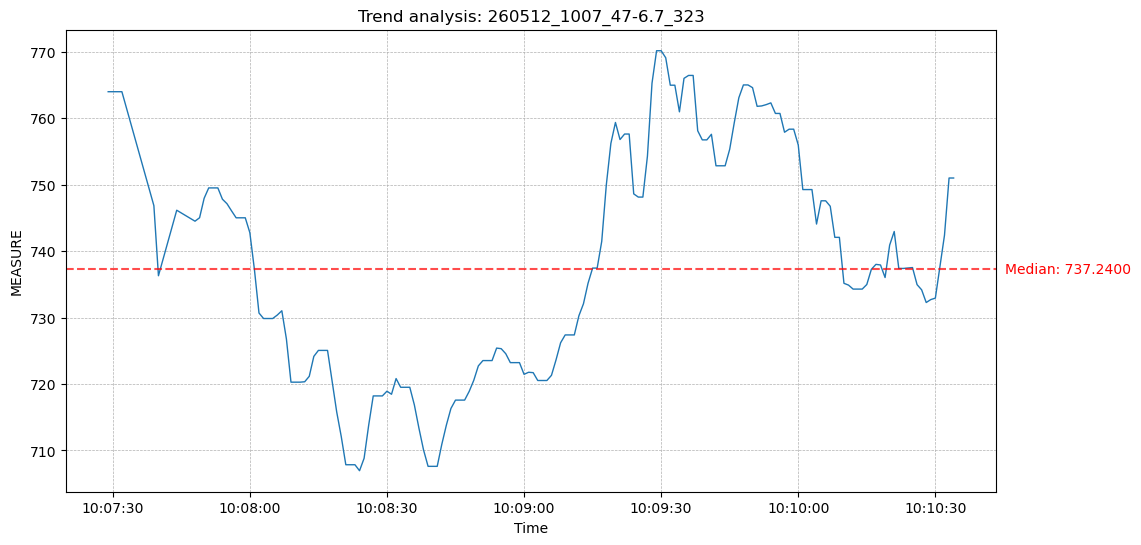

Generating trend plot for: MEASURE in 260512_1010_47-6.7_323.csv


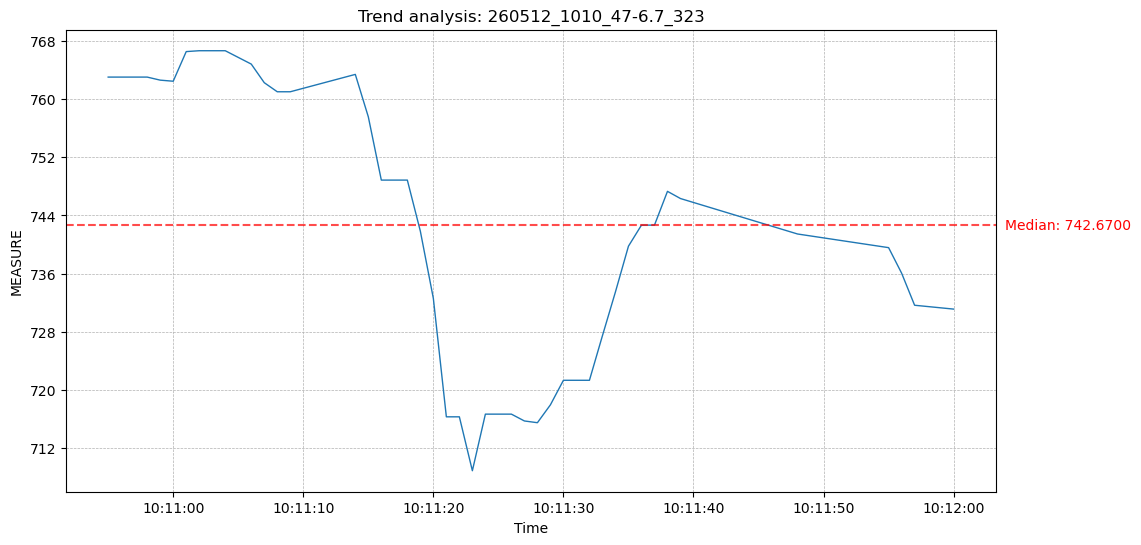

In [13]:
for target_file in target_files:
    df = load_csv(target_file)
    if df is None: continue

    # Define candidate variables and pick the first one available that is numeric
    candidates = ["MEASURE", "A Flow velocity [m/s]", "SSPEED"]
    variable = next((c for c in candidates if c in df.columns), None)

    # If candidates aren't found or aren't numeric, fallback to any numeric column
    if not variable or pd.to_numeric(df[variable], errors='coerce').dropna().empty:
        numeric_cols = df.select_dtypes(include=['number']).columns
        variable = numeric_cols[0] if not numeric_cols.empty else None

    if variable:
        print(f"Generating trend plot for: {variable} in {target_file.name}")
        fig_trend = create_plot(df, variable, title=f"Trend analysis: {target_file.stem}")
        plt.show()
    else:
        print(f"No numeric variables found to plot in {target_file.name}.")

### 3. Create Boxplot

Generating boxplot for: MEASURE in 260512_1007_47-6.7_323.csv


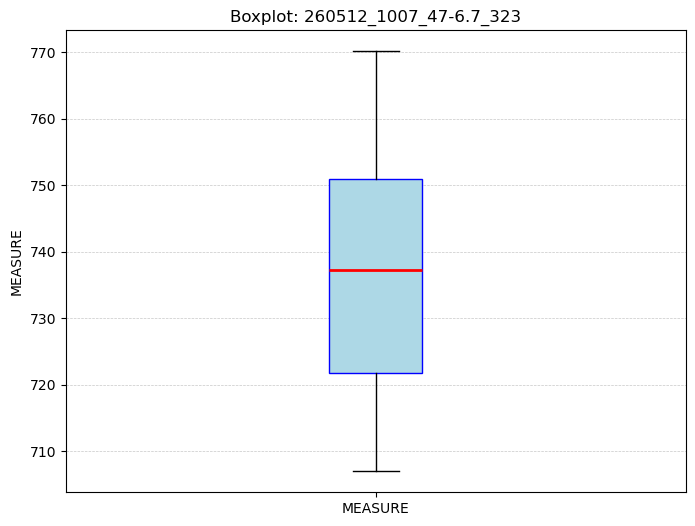

Generating boxplot for: MEASURE in 260512_1010_47-6.7_323.csv


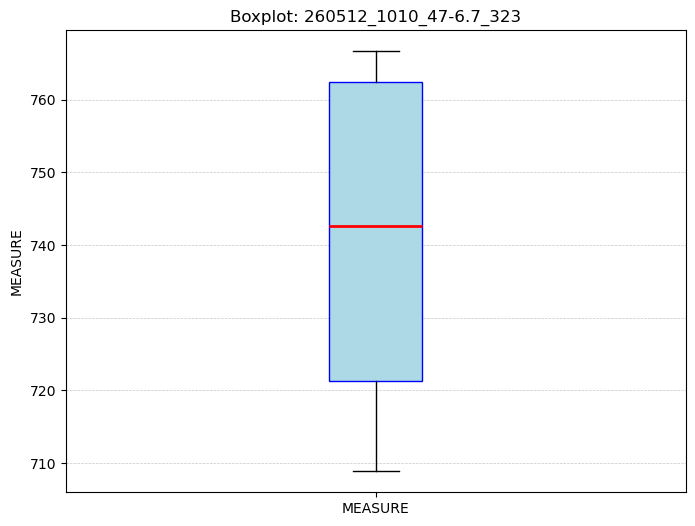

In [14]:
for target_file in target_files:
    df = load_csv(target_file)
    if df is None: continue

    # Detect the best variable for THIS specific file
    candidates = ["MEASURE", "A Flow velocity [m/s]", "SSPEED"]
    variable = next((c for c in candidates if c in df.columns), None)

    if not variable or pd.to_numeric(df[variable], errors='coerce').dropna().empty:
        numeric_cols = df.select_dtypes(include=['number']).columns
        variable = numeric_cols[0] if not numeric_cols.empty else None

    if variable:
        print(f"Generating boxplot for: {variable} in {target_file.name}")
        fig_box = create_boxplot(df, variable, title=f"Boxplot: {target_file.stem}")
        plt.show()
    else:
        print(f"No numeric variables found to plot in {target_file.name}.")